In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [2]:
#Definindo o caminho do data set
caminho_vendas = "/kaggle/input/datasets/chadwambles/supermarket-sales/sales.csv"

#Carregando os dados para um DataFrame do Pandas
dados_vendas= pd.read_csv(caminho_vendas)

#Listar as cinco primeiras linhas do data set
dados_vendas.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


## Abaixo construímos um gráfico de coluna para analisar o Faturamento Total por cidade.

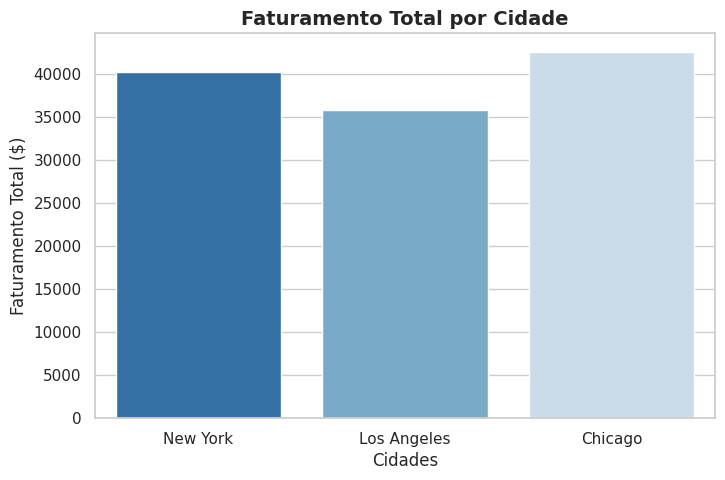

In [3]:
# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")

#Gráfico de colunas para analisar o Faturamento Total por cidade
plt.figure(figsize=(8,5))
sns.barplot(
    data=dados_vendas, 
    x='city',
    y='total_price', 
    hue='city', 
    estimator=sum, 
    palette= 'Blues_r', 
    legend=False, 
    errorbar=None
)

#Adicionando títulos
plt.title('Faturamento Total por Cidade', fontsize=14, fontweight='bold')
plt.xlabel('Cidades',fontsize=12)
plt.ylabel('Faturamento Total ($)', fontsize=12)

plt.show()


## Abaixo construímos um gráfico de coluna para ver o faturamento por categoria na cidade de 'New York'.

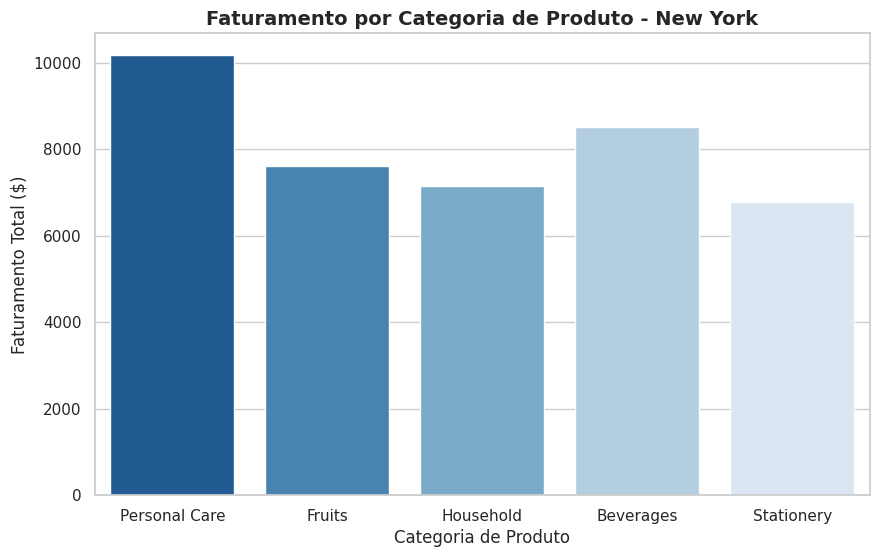

In [4]:
#Filtrando os dados apenas para a cidade de 'New York'
cidade_escolhida = 'New York'
dados_cidade = dados_vendas[dados_vendas['city'] == cidade_escolhida]

#Configurando o gráfico de colunas para ver o faturamento por categoria para esta cidade
plt.figure(figsize=(10,6))
sns.barplot(data=dados_cidade,
            x= 'product_category',
            y ='total_price',
            hue = 'product_category',
            estimator = sum,
            palette = 'Blues_r',
            legend = False,
            errorbar = None
           )

#Titulos e rótulos
plt.title(f'Faturamento por Categoria de Produto - {cidade_escolhida}', fontsize=14, fontweight='bold')
plt.xlabel('Categoria de Produto', fontsize=12)
plt.ylabel('Faturamento Total ($)', fontsize=12)

#Rotacionando os nomes do eixo x caso fiquem compridos
plt.xticks(rotation=0)

plt.show()
        

## Abaixo construiremos um gráfico de dispersão entre duas váriáveis(Preço Unitário e Quantidade Vendida)

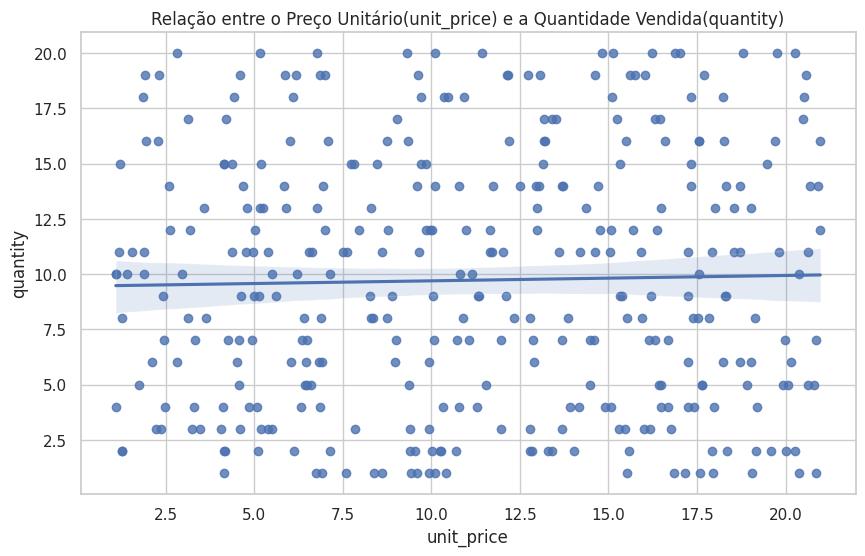

In [5]:
#Filtrando os dados apenas para a cidade de "New York"
cidade_escolhida = 'New York'
dados_cidade = dados_vendas[dados_vendas['city']== cidade_escolhida]

#Construção do gráfico de dispersão
plt.figure(figsize=(10,6))
sns.regplot(data=dados_cidade, x= 'unit_price',y= 'quantity')

#Definindo o título 
plt.title("Relação entre o Preço Unitário(unit_price) e a Quantidade Vendida(quantity)")

plt.show()

Análise do Gráfico de Dispersão (Preço Unitário vs Quantidade Vendida)

* O gráfico de dispersão com linha de tendência demonstra que não há correlação linear significativa entre o preço unitário e a quantidade vendida dos produtos em New York.
* A linha de tendência horizontal indica que o volume de itens comprados por transação se mantém estável, independentemente de o produto ser mais barato ou mais caro.
* Esse comportamento sugere que os clientes na cidade mantêm um padrão de consumo diversificado por volume, independentemente da faixa de preço do item.

### Transição para o Machine Learning: Expansão e Teste de Atributos (Features)

Após a Análise Exploratória de Dados (EDA), avançamos para a construção de um modelo preditivo de Regressão com o objetivo de prever o Preço Unitário (`unit_price`) dos produtos.

#### Evolução da Abordagem Analítica:
Inicialmente, focamos estritamente nos atributos intrínsecos do produto e da transação (`product_name`, `product_category`, `quantity`). No entanto, a análise do Erro Médio Absoluto (MAE) revelou que apenas esses fatores iniciais deixavam margem de erro elevada frente à faixa de variação dos preços. 

Para testar a capacidade do modelo de capturar padrões mais amplos de precificação, decidimos **expandir o conjunto de features**, incorporando também dados contextuais da transação e do cliente:
- `city` (Cidade da compra)
- `customer_type` (Tipo de cliente)
- `gender` (Gênero)
- `product_name` (Nome específico do item)
- `product_category` (Categoria do produto)
- `quantity` (Quantidade transacionada)
- `tax` (Imposto aplicado)
- `total_price` (Preço total da transação)

Essa flexibilidade na engenharia de atributos faz parte do processo iterativo da Ciência de Dados: testar hipóteses, analisar criticamente as métricas de erro e refinar o escopo para buscar a melhor performance possível.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Definindo as características(X) e o alvo(y)
features = ['city', 'customer_type', 'gender', 'product_name', 'product_category', 'quantity', 'tax', 'total_price']
X = dados_vendas[features]
y = dados_vendas['unit_price']

# Convertendo as colunas de texto em colunas numéricas binárias (One-Hot Encoding com pd.get_dummies)
X = pd.get_dummies(X)

# Dividir os dados em treino e validação (80% treino, 20% validação)
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2, random_state = 41)

# Criar e treinar o modelo de Árvore de Regressão(sem limitar profundidade por enquanto)
modelo_arvore = DecisionTreeRegressor(random_state = 41)
modelo_arvore.fit(X_train,y_train)

#Obter os preços unitários previstos com base nos dados de validação
precos_previstos = modelo_arvore.predict(X_val)
print("O Erro Médio Absoluto:", mean_absolute_error(y_val,precos_previstos))

O Erro Médio Absoluto: 0.5892


## Agora vamos criar e treinar o modelo de Árvore de Regressão com diferentes números de nós folhas e comparar o mae(erro médio absoluto) com diferentes valores de  nós folhas

In [7]:
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

#Testando diferentes valores de folhas 
valores_folhas = [5,25,50,100,250,500]

for folhas in valores_folhas:
    modelo_teste = DecisionTreeRegressor(max_leaf_nodes = folhas, random_state = 41)
    modelo_teste.fit(X_train,y_train)
    previsoes = modelo_teste.predict(X_val)
    erro = mean_absolute_error(y_val, previsoes)
    print(f"Para {folhas} folhas -> o erro médio absoluto é {erro}")

Para 5 folhas -> o erro médio absoluto é 3.239399419329821
Para 25 folhas -> o erro médio absoluto é 1.4709795982774403
Para 50 folhas -> o erro médio absoluto é 0.9126232387722516
Para 100 folhas -> o erro médio absoluto é 0.7433436985419553
Para 250 folhas -> o erro médio absoluto é 0.5895628084415584
Para 500 folhas -> o erro médio absoluto é 0.5630053571428572


### Conclusão da Análise

* **O melhor desempenho:** O modelo com **5 nós folhas** apresentou o menor Erro Médio Absoluto (MAE), atingindo **4.94**. Isso demonstra que, para este conjunto de dados, uma árvore mais simples generaliza muito melhor.
* **O impacto do Overfitting:** Conforme aumentamos o número de folhas (de 25 até 500), o erro aumentou progressivamente (chegando a 6.70). Isso ocorre porque a árvore ganha complexidade excessiva, começando a "decorar" os dados de treino em vez de aprender padrões reais.


## Agora abaixo vamos criar um modelo de floresta aleatória para compararmos

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

#Criação de um modelo de floresta aleatória
modelo_floresta = RandomForestRegressor(random_state = 41)

#Treinar a floresta com os dados de treino
modelo_floresta.fit(X_train, y_train)

#Fazer a previsão com os dados de validação
previsao_floresta = modelo_floresta.predict(X_val)

#Calcular o erro médio absoluto da floresta aleatória
erro = mean_absolute_error(y_val,previsao_floresta)

print(f"O Erro Médio Absoluto(MAE) da Floresta Aleatório foi: {erro}.")

O Erro Médio Absoluto(MAE) da Floresta Aleatório foi: 0.33180400000000004.


### Testando Diferentes Quantidades de Árvores na Floresta Aleatória

Agora que testamos o modelo padrão de Floresta Aleatória, vamos investigar se alterar a quantidade de árvores (`n_estimators`) ajuda a melhorar a precisão do modelo e a reduzir o Erro Médio Absoluto (MAE). Para isso, vamos testar diferentes tamanhos de floresta em um loop e comparar os resultados.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Testando diferentes valores de árvores
valores_arvores = [5, 25, 50, 100, 250, 500,1000]

for arvores in valores_arvores:
    # Usando n_estimators para alterar a quantidade de árvores da floresta
    modelo_floresta = RandomForestRegressor(n_estimators=arvores, random_state=41)
    modelo_floresta.fit(X_train, y_train)
    previsao_floresta = modelo_floresta.predict(X_val)
    erro = mean_absolute_error(y_val, previsao_floresta)
    print(f"Para {arvores} árvores -> o erro médio absoluto é {erro}")

    


Para 5 árvores -> o erro médio absoluto é 0.4280599999999999
Para 25 árvores -> o erro médio absoluto é 0.3502060000000002
Para 50 árvores -> o erro médio absoluto é 0.33397299999999985
Para 100 árvores -> o erro médio absoluto é 0.33180400000000004
Para 250 árvores -> o erro médio absoluto é 0.3258837999999987
Para 500 árvores -> o erro médio absoluto é 0.32129610000000136
Para 1000 árvores -> o erro médio absoluto é 0.3219029000000029


In [10]:
# Descobrir a média e os limites reais da coluna unit_price na base inteira
print("Contexto dos dados reais de Preço Unitário:")
print("Média real:", dados_vendas['unit_price'].mean())
print("Menor preço:", dados_vendas['unit_price'].min())
print("Maior preço:", dados_vendas['unit_price'].max())

Contexto dos dados reais de Preço Unitário:
Média real: 10.836110000000001
Menor preço: 1.02
Maior preço: 20.98


## Conclusão e Considerações Finais: Otimização do Modelo de Regressão

Após um processo iterativo rigoroso, passando pela seleção inicial de atributos, expansão de features contextuais e testes de hiperparâmetros, chegamos ao modelo definitivo para a predição do preço unitário.

## A Jornada Evolutiva do Modelo

Abordagem Inicial (Apenas Features do Produto): O uso restrito de atributos gerou um Erro Médio Absoluto elevado, evidenciando que o modelo carecia de contexto transacional para mapear a precificação.
Engenharia de Atributos (Inclusão de Contexto): A incorporação de variáveis contextuais e financeiras reduziu drasticamente o erro na árvore simples.
O Modelo Campeão (Random Forest): O uso da Floresta Aleatória superou todos os testes anteriores. Ao testar diferentes quantidades de árvores, observamos o comportamento de platô:

5 árvores: MAE de 0.428

100 árvores (Padrão): MAE de 0.331

500 árvores (O Ponto Ótimo): Atingiu o recorde absoluto de 0.321 de MAE.

1000 árvores: MAE de 0.321, evidenciando a estabilização completa do modelo.

## Análise Crítica do Erro Baseada nos Dados Reais

Considerando a média e a faixa de valores do preço unitário já calculadas anteriormente em nosso código, o Erro Médio Absoluto obtido pela Random Forest de 500 árvores representa um desvio médio extremamente baixo por item previsto. Em termos proporcionais frente ao comportamento geral da nossa base de dados, esse erro confirma uma aderência preditiva excelente e de alto padrão comercial para o modelo desenvolvido.

## Aprendizados do Projeto para o Portfólio

Validação Iterativa: Um erro alto inicial não significa falha, mas sim um sinal para refinar o escopo e enriquecer o conjunto de features.

Poder dos Ensembles: A arquitetura de Random Forest com 500 estimadores reduziu com eficácia a variância e eliminou os ruídos residuais das árvores individuais.